# Estimation of the intensity of a point process

In [14]:
import sys
sys.path.append("../..")
from src.point_process import *
import matplotlib.pyplot as plt
import time
from src.utils import format_time, color
import json

**Example 2: _Thomas_ process**

Let's test our intensity estimators on a _Thomas_ process.

In [15]:
with open('../../parameters/thomas-process-m-06.json', 'r') as file:
    params = json.load(file)

In [16]:
W = params['W']
w, h = W
lam_p = params['lam_p']
nu = params['nu'] 
sig = params['sig']

In [17]:
thomas_process = ThomasProcess(lam_p, nu, sig)
parents, points_thomas = thomas_process.generate(W, seed=42)

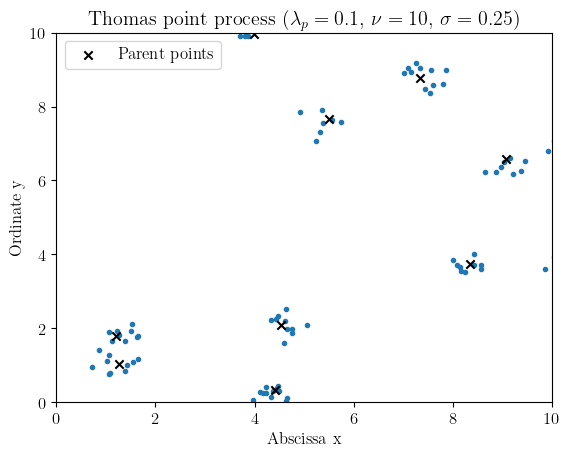

In [ ]:
display(parents, points_thomas, window=(10, 10), title=fr"Thomas point process ($\lambda_p = {lam_p}$, $\nu = {nu}$, $\sigma = {sig}$)")

In [19]:
def intensities(points: np.ndarray, W:tuple[float, float], start: float, n_steps: int = 100, verbose: bool = False):
    
    w, h = W
    a_range = np.linspace(start, w, n_steps)
    b_range = np.linspace(start, h, n_steps)

    intensities = np.zeros((n_steps))

    if verbose: t_init = time.time()
    for i, (a, b) in enumerate(zip(a_range, b_range)):
        trimmed_points = trim_process(points, bottom_left=(0, 0), W=(a, b))
        intensities[i] = intensity(trimmed_points, W=(a, b))
        if verbose: print(f'--> Step {i+1:03}/{n_steps}'.rjust(18, " ") + f' -- Elapsed time: {format_time(time.time() - t_init)}')
        
    area_range = a_range*b_range
    return area_range, intensities

In [20]:
area_range, intensities_poisson = intensities(points_thomas, W, 10)

<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_770230/381665570.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Intensity estimate $\hat{\lambda}$')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


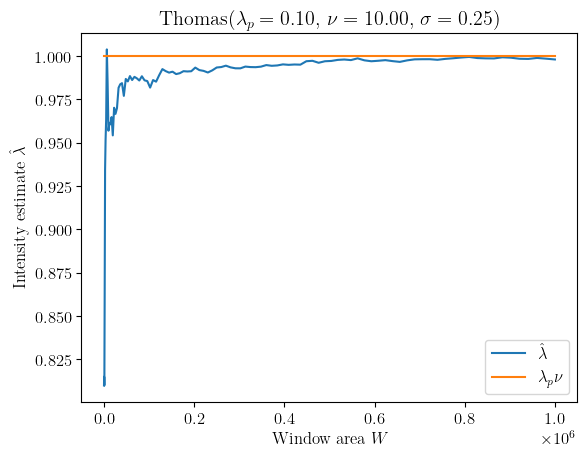

In [41]:
plt.plot(area_range, intensities_poisson, label=r'$\hat{\lambda}$')
plt.plot(area_range, np.full_like(area_range, lam_p*nu), label =r'$\lambda_p \nu$')
plt.legend()

plt.xlabel('Window area $W$')
plt.ylabel('Intensity estimate $\hat{\lambda}$')
plt.title(fr'Thomas($\lambda_p = {lam_p: .2f}$, $\nu = {nu: .2f}$, $\sigma = {sig: .2f}$)')

plt.savefig('../../img/intensity-estim-3.eps', format='eps')
plt.show()